# Итоговый проект: «От дерева решений к ансамблю и кластеризации»

#### Задание

**Проект** поможет увидеть, как на практике решаются задачи анализа данных — от простых правил до более сложных алгоритмов.

Вы научитесь строить алгоритмы, которые сами находят закономерности в данных, и поймёте, как такие методы применяются, например, при разделении клиентов на группы, прогнозе событий или оценке качества решений.

Проект даст вам опыт «взрослой» аналитической работы, когда нужно не просто обработать таблицу, а объяснить, почему модель принимает именно такие решения.

**Цель проекта**

Цель проекта — закрепить понимание принципов работы алгоритмов деревьев решений, ансамблей и кластеризации через собственную реализацию и анализ их поведения на данных.

В ходе проекта вы:

* реализуете базовые версии алгоритмов с нуля, используя numpy и pandas;
* проведёте эксперименты с параметрами и сравните результаты с реализациями из sklearn;
* научитесь интерпретировать результаты и визуализировать их.

**Формат выполнения**
1. Проект выполняется индивидуально.
2. Результат — Jupyter Notebook (.ipynb):
    * с описанием цели и задач проекта;
    * кодом с комментариями;
    * визуализациями и таблицами;
    * краткими выводами по каждому этапу.
3. В конце ноутбука добавьте общий вывод: чему вы научились и какие особенности алгоритмов заметили.

## Этап 1. Реализация дерева решений (15 баллов)
На этом этапе вы создаёте простую реализацию дерева решений для задачи классификации.

### Что нужно сделать

1. Сгенерируйте небольшой набор данных (100–300 наблюдений) с помощью функции:

```from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=200,
    n_features=2,  # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)
```
2. Преобразуйте данные в pandas.DataFrame.

3. Реализуйте функции:

* расчёта критерия Джини или энтропии;
* поиска наилучшего разбиения по признаку;
* рекурсивного построения дерева с ограничением по глубине (max_depth) или по числу объектов в узле (min_samples_split);
* предсказания для новых наблюдений.

**Тестирование модели**
1. Разделите данные на обучающую и тестовую выборки (например, с помощью train_test_split, зафиксировав random_state=42 для воспроизводимости).
2. Сравните результаты своей реализации с DecisionTreeClassifier из sklearn. Разрешается использовать этот класс только для сверки корректности.
3. Постройте график границ решений (если данных 2D) с помощью matplotlib.

**Результат**
* Таблица с точностью (accuracy) на обучении и тесте.
* Визуализация дерева или границ решений.
* Краткий комментарий о различиях вашей реализации и sklearn.

### Решение

In [1]:
# Импортируем необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


,feature_1,feature_2,target
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,0
3,-2.585395,0.963532,0
4,1.372246,0.440695,1


target
1    100
0    100
Name: count, dtype: int64

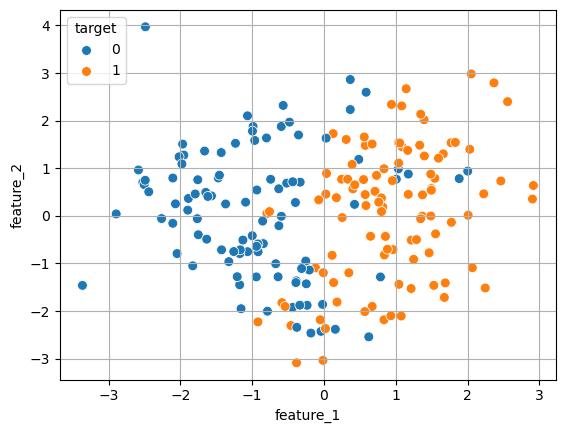

In [2]:
# Генерация данных
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
)

# Преобразование в pandas.DataFrame
# Объединяем признаки X и целевую переменную y в один DataFrame
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
# преобразуем "X" в DataFrame
X = df.copy()
df['target'] = y
# преобразуем "y" в DataFrame
y = df['target']

# вывод значений целевой переменной
display(df.head())
display(df.target.value_counts())
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target', s=50) # s - размер точек, hue - категория цвета
plt.legend(title='target') # Добавляем легенду
plt.grid(True) # Необязательно: добавляем сетку
plt.show()

In [3]:
# Заводим класс и функции
class Node:
    def __init__(self, left=None, 
                 right=None, value=None, 
                 split_params=None, impurity=None,
                 samples=None, is_leaf=False):
        self.left = left
        self.right = right
        self.split_params = split_params
        self.value = value
        self.impurity = impurity
        self.samples = samples
        self.is_leaf = is_leaf


def find_candidates_for_thresholds(x, y):
    x = x.sort_values().drop_duplicates()
    x_roll_mean = x.rolling(2).mean().dropna()
    y = y[x_roll_mean.index]
    y_roll_mean = y.diff()
    candidates = x_roll_mean[y_roll_mean != 0]
    return candidates.values

def squared_error(y):
    y_pred = y.mean()
    return ((y - y_pred) ** 2).mean()

def gini(y):
    p = y.value_counts(normalize=True)
    gini_impurity = 1 - np.sum(p**2)
    return gini_impurity

def entropy(y):
    p = y.value_counts(normalize=True)
    entropy = -np.sum(p * np.log2(p))
    return entropy

def split(X, y, split_params):
    j, t = split_params
    predicat = X.iloc[:, j] <= t
    X_left, y_left = X[predicat], y[predicat]
    # В pandas для булевой индексации необходимо использовать побитовые операторы ~ (NOT), & (AND), | (OR).
    X_right, y_right = X[~predicat], y[~predicat]
    return X_left, y_left, X_right, y_right

def calculate_weighted_impurity(X, y, split_params, criterion):
    X_left, y_left, X_right, y_right = split(X, y, split_params)
    N, N_left, N_right  = y.size, y_left.size, y_right.size
    score = N_left / N * criterion(y_left) + N_right / N * criterion(y_right)
    return score

def best_split(X, y, criterion):
    M = X.shape[1]
    min_weighted_impurity = np.inf
    optimal_split_params = None
    for j in range(M):
        thresholds = find_candidates_for_thresholds(X.iloc[:, j], y)
        for t in thresholds:
            split_params = (j, t)
            weighted_impurity = calculate_weighted_impurity(X, y, split_params, criterion)
            if weighted_impurity < min_weighted_impurity:
                min_weighted_impurity = weighted_impurity
                optimal_split_params = split_params
    return optimal_split_params

def create_leaf_prediction(y):
    value = y.mode()[0]
    return value

def stopping_criterion(X, y, criterion, max_depth=None, depth=0):
    if max_depth is None:
        return (criterion(y) == 0) 
    else:
        return (criterion(y) == 0) or (depth > max_depth)
    
def build_decision_tree(X, y, criterion, max_depth=None, depth=0):
    depth += 1
    if stopping_criterion(X, y, criterion, max_depth, depth):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion)
        X_left, y_left, X_rigth, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion, max_depth, depth)
        right = build_decision_tree(X_rigth, y_right, criterion, max_depth, depth)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    return node

def print_decision_tree(node, depth=0):
    depth += 1
    if node.is_leaf:
        print('   ' * depth, 'class: {}'.format(node.value))
    else:
        print('   ' * depth, 'feature_{} <= {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.left, depth=depth)
        print('   ' * depth, 'feature_{} > {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.right, depth=depth)

def predict_sample(node, x):
    if node.is_leaf:
        return node.value
    j, t = node.split_params
    if x[j] <= t:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)  

def predict(decision_tree, X):
    if isinstance(X, np.ndarray):    
        X = pd.DataFrame(X)
    predictions = [predict_sample(decision_tree, x) for x in X.values]
    return np.array(predictions)


print("Количество кандидатов для разбиения - feature_1:", 
      find_candidates_for_thresholds(df['feature_1'], df['target']).shape[0])
print("Количество кандидатов для разбиения - feature_2:", 
      find_candidates_for_thresholds(df['feature_2'], df['target']).shape[0])
print("-"*63)

# Находим оптимальные параметры разбиения
criterion_list = [gini, entropy, squared_error]
for elem in criterion_list:
    optimal_split_params = best_split(X, y, criterion=elem)
    print(str(elem).split()[1], '-'*5, 'Optimal j: {}'.format(optimal_split_params[0]), 'Optimal t: {}'.format(optimal_split_params[1]))


Количество кандидатов для разбиения - feature_1: 38
Количество кандидатов для разбиения - feature_2: 110
---------------------------------------------------------------
gini ----- Optimal j: 0 Optimal t: -0.1502000994422335
entropy ----- Optimal j: 0 Optimal t: -0.1502000994422335
squared_error ----- Optimal j: 0 Optimal t: -0.1502000994422335


Наше дерево решений
    feature_0 <= -0.150:
       class: 0
    feature_0 > -0.150:
       class: 1
Sklearn дерево решений
    feature_0 <= -0.150:
       class: 0
    feature_0 > -0.150:
       class: 1
РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
              Модель  Accuracy на обучении  Accuracy на тесте  Accuracy на всём
         Наше дерево                   0.9              0.825             0.885
Sklearn DecisionTree                   0.9              0.825             0.885



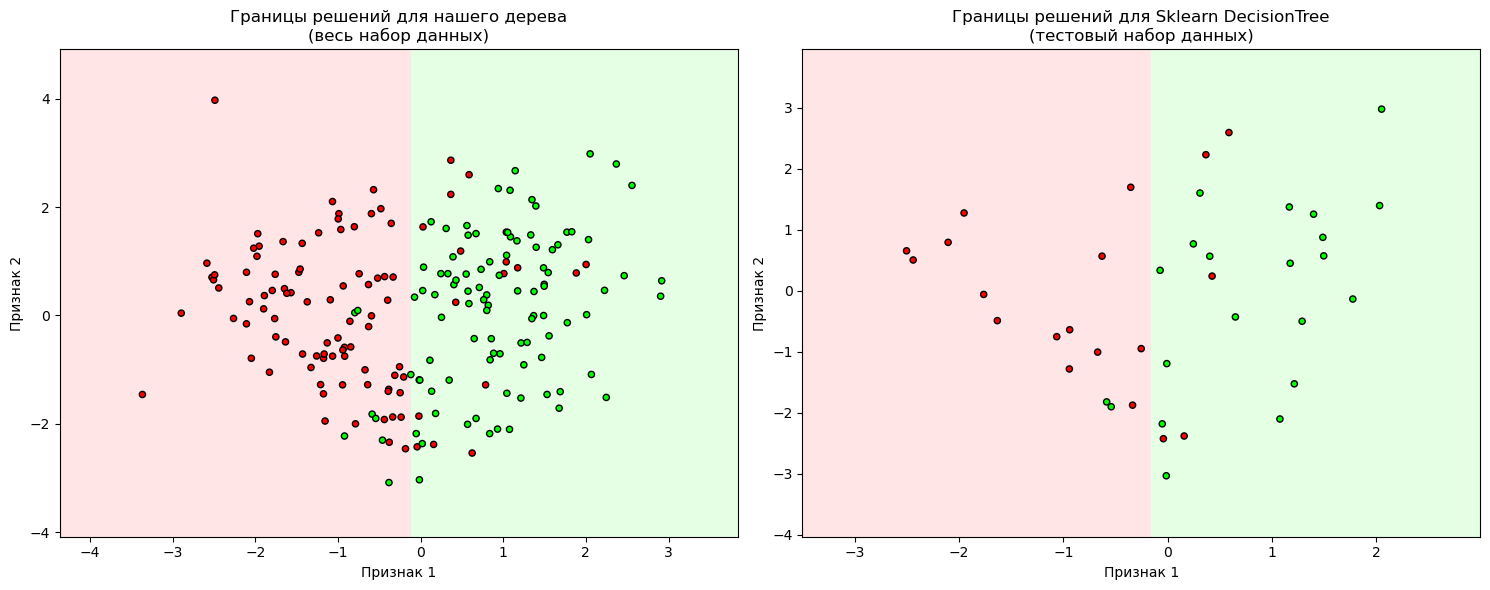

In [17]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Параметры модели
max_depth=1
criterion=gini

# Обучение нашей модели
decision_tree = build_decision_tree(X_train, y_train, max_depth=max_depth, criterion=criterion,)

print("Наше дерево решений")
print_decision_tree(decision_tree)

# Предсказания
y_train_pred_custom = predict(decision_tree, X_train)
y_test_pred_custom = predict(decision_tree, X_test)
y_total_pred_custom = predict(decision_tree, X)

# Обучение sklearn модели для сравнения
sklearn_tree = DecisionTreeClassifier(
    max_depth=max_depth, 
    random_state=42
)
sklearn_tree.fit(X_train.values, y_train.values)
print("Sklearn дерево решений")
print_decision_tree(decision_tree)

y_train_pred_sklearn = sklearn_tree.predict(X_train.values)
y_test_pred_sklearn = sklearn_tree.predict(X_test.values)
y_total_pred_sklearn = sklearn_tree.predict(X.values)

# Вычисление accuracy
train_acc_custom = accuracy_score(y_train, y_train_pred_custom)
test_acc_custom = accuracy_score(y_test, y_test_pred_custom)
total_acc_custom = accuracy_score(y, y_total_pred_custom)

train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)
total_acc_sklearn = accuracy_score(y, y_total_pred_sklearn)

# Создание таблицы с результатами
results_df = pd.DataFrame({
    'Модель': ['Наше дерево', 'Sklearn DecisionTree'],
    'Accuracy на обучении': [train_acc_custom, train_acc_sklearn],
    'Accuracy на тесте': [test_acc_custom, test_acc_sklearn],
    'Accuracy на всём': [total_acc_custom, total_acc_sklearn],
})

print("=" * 80)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n" + "=" * 80)

# Визуализация границ решений
def plot_decision_boundaries(model, X, y, title, ax):
    """Функция для визуализации границ решений"""

    if isinstance(X, pd.DataFrame):
        X = X.values
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    # Сетка для построения границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Предсказания для точек сетки    
    if hasattr(model, 'predict_proba'):
        # тогда это sklearn
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = predict(model, np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    
    # Построение границ
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация для нашего дерева
plot_decision_boundaries(decision_tree, X, y, 
                        'Границы решений для нашего дерева\n(весь набор данных)', axes[0])

# Визуализация для sklearn дерева
plot_decision_boundaries(sklearn_tree, X_test, y_test,  
                        'Границы решений для Sklearn DecisionTree\n(тестовый набор данных)', axes[1])

plt.tight_layout()
plt.show()

### Выводы:

1. В целом решение с нуля показало примерно тот же результат (*accuracy*), что и библиотечное решение.
     * Регулированием параметром глубины ветвления (*max_depth*) можно достичь, как лучших, так и худших результатов на тестовой выборке (при этом разница только во втором, в треьем знаке после запятой).
     * Самый лучший результат дало ограничение на не более, чем на **одно** разделение (*accuracy* на тестовом наборе 82,5%).
3. Изменение критерия Джини на критерий энтропии Шеннона не показало никаких видимых результатов.
4. Регулировка параметра ```max_depth``` - важный этап, так мы не позволяем можели переобучиться, когда она начинает вырезать области под конкретные точки, что даёт 100% *accuracy* на тренировочном наборе, но эти мелкие вырезы только ухудшают результат на тестовом наборе (70% *accuracy*).


## Этап 2. Ансамбль деревьев (бэггинг)


### Задание

**Что нужно сделать**

1. Напишите функцию, которая:
   * случайно выбирает bootstrap-выборку (с возвращением) из обучающих данных размером, равным обучающей выборке;
   * обучает на ней одно дерево решений;
   * сохраняет модель.
2. Повторите процесс несколько раз — например, для N = 5, 10, 20.
3. Для объединения предсказаний:
   * при классификации используйте большинство голосов;
   * если реализуете предсказания вероятностей, усредняйте вероятности по всем деревьям и выбирайте класс с наибольшим средним значением.
4. Чтобы результаты были воспроизводимыми, фиксируйте random_state при генерации каждой подвыборки (например, random_state=i внутри цикла).
5. Сравните качество классификации одного дерева и ансамбля.
6. Постройте график зависимости точности от количества деревьев.

**Результат**
* Таблица с результатами для разных N.
* График зависимости качества от числа деревьев.
* Вывод: как ансамбль влияет на качество и устойчивость модели.

### Решение